In [1]:
using CovidSim_ilm

In [2]:
cs = CovidSim_ilm

CovidSim_ilm

In [3]:
using StatsBase
using LazyTables
using BenchmarkTools
using Distributions
using YAML
using PrettyPrint
using LinearAlgebra
using Dates
using Plots
using SplitApplyCombine
using Tables
using PrettyTables

In [4]:
cd(joinpath(homedir(),"Dropbox/Covid Modeling/Covid-ILM/src"))

# Test setup and population matrix

In [ ]:
ndays = 180
locale = 38015
model180 = buildsim(
    ndays, locale;  
    day1 = Date("2020-01-01", "yyyy-mm-dd"),
    dovax = true,
    paramdir = "../sample_parameters",
    geofilename = "geo2data.csv", 
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    scheddir = "vaccine_100k",
    variantfilename = "variants.yml",
);

# Run the small model

### Seed with base variant on day 1

In [6]:
seed20_39_day1 = makesickseedfunc(; cond=:nil, variant=:base, duration=1, filter=[Term(:agegrp, :age20_39), Term(:status, :unexposed)], 
                            cnt=3, forlocale=0, triggerdate=1, forstartofday=true);
seed40_59_day1 = makesickseedfunc(; cond=:nil, variant=:base, duration=1, filter=[Term(:agegrp, :age40_59), Term(:status, :unexposed)], 
                            cnt=3, forlocale=0, triggerdate=1, forstartofday=true);           

### Run and Compile

In [10]:
popdat, series = runsim(model180;
            dovax=false, vaxscheds=:all,
            runcases=[seed20_39_day1, seed40_59_day1]   
            );
locdat = popdat[locale];

*** seed day 1 count: 3 filter: [agegrp=:age20_39, status=:unexposed, ] change: [status=:infectious, cond=:nil, sickday=1, variant=:base, duration=1, ]
*** seed day 1 count: 3 filter: [agegrp=:age40_59, status=:unexposed, ] change: [status=:infectious, cond=:nil, sickday=1, variant=:base, duration=1, ]

Execution Times
Indexing     0.014
Vaccination  0.000
Spread       0.323
Progression  0.130
History      0.111
Total        0.607


### Plot results

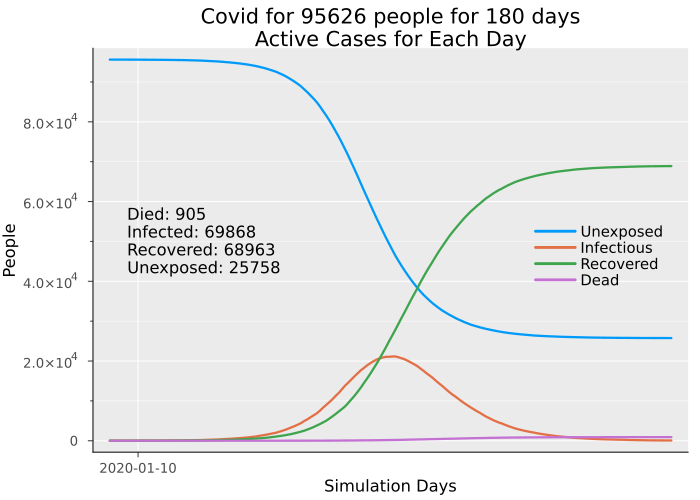

In [11]:
cumplot(series, locale, [:unexposed, :infectious, :recovered, :dead])

### R0 Simulation

In [10]:
r0 = cs.r0_sim(200_000, model180.progressionset, model180.trvec, model180.infectset, 
                model180.vaxset, model180.social, false, :base, 1.0, 3)

LoadError: MethodError: no method matching progression!(::Int64, ::OrderedCollections.LittleDict{Symbol, Infectparams, Vector{Symbol}, Vector{Infectparams}}, ::Dict{Symbol, CovidSim_ilm.ProgressionParams}, ::Dict{Symbol, Vaccineparams}, ::Bool, ::typeof(CovidSim_ilm.noop), ::Vector{Float64}, ::Vector{Symbol}, ::Vector{Symbol}, ::Vector{Symbol}, ::Vector{Int64}, ::Vector{Symbol}, ::Vector{Vector{Symbol}}, ::Vector{Symbol}, ::Vector{Vector{Int64}}, ::Vector{Vector{Symbol}}, ::Vector{Vector{Int64}}, ::Vector{Int64})

[0mClosest candidates are:
[0m  progression!(::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any)
[0m[90m   @[39m [35mCovidSim_ilm[39m [90m~/.julia/packages/CovidSim_ilm/5uI52/src/[39m[90m[4mprogression.jl:20[24m[39m


In [36]:
keys(model180)

(:ndays, :day1, :locales, :dat, :series, :geo, :progressionset, :vaxset, :vaxschedset, :infectset, :social, :trvec, :variantlist, :vaxlist, :indoor_seq, :seriescolnames)

In [16]:
typeof(model180.seriescolnames)

Dict{Symbol, Dict{Symbol, Dict{Symbol, Symbol}}}

In [17]:
model180.seriescolnames

Dict{Symbol, Dict{Symbol, Dict{Symbol, Symbol}}} with 4 entries:
  :condcols    => Dict(:sick=>Dict(:age40_59=>:sick_age40_59, :age60_79=>:sick_…
  :vaxcols     => Dict(:totvaccinated=>Dict(:age40_59=>:totvaccinated_age40_59,…
  :variantcols => Dict(:alpha=>Dict(:age40_59=>:alpha_age40_59, :age60_79=>:alp…
  :statuscols  => Dict(:infectious=>Dict(:age40_59=>:infectious_age40_59, :age6…

In [18]:
scn = model180.seriescolnames
@btime scn[:condcols][Symbol(sick)][Symbol(age0_19)]

LoadError: UndefVarError: `sick` not defined

In [ ]:
@btime Symbol(:sick, "_", age0_19)

### Data tables

In [54]:
locdat = model180.dat.popdat[locale]

Table with 17 columns and 95626 rows:
      status     agegrp   cond        duration  variant   sickday  recovday  ⋯
    ┌─────────────────────────────────────────────────────────────────────────
 1  │ unexposed  age0_19  uninfected  0         Symbol[]  [0]      [0]       ⋯
 2  │ unexposed  age0_19  uninfected  0         Symbol[]  [0]      [0]       ⋯
 3  │ unexposed  age0_19  uninfected  0         Symbol[]  [0]      [0]       ⋯
 4  │ unexposed  age0_19  uninfected  0         Symbol[]  [0]      [0]       ⋯
 5  │ unexposed  age0_19  uninfected  0         Symbol[]  [0]      [0]       ⋯
 6  │ unexposed  age0_19  uninfected  0         Symbol[]  [0]      [0]       ⋯
 7  │ unexposed  age0_19  uninfected  0         Symbol[]  [0]      [0]       ⋯
 8  │ unexposed  age0_19  uninfected  0         Symbol[]  [0]      [0]       ⋯
 9  │ unexposed  age0_19  uninfected  0         Symbol[]  [0]      [0]       ⋯
 10 │ unexposed  age0_19  uninfected  0         Symbol[]  [0]      [0]       ⋯
 11 │ unexpose

In [9]:
ages = model180.dat.agegrp_idx[locale]

Dict{Agegrp, Vector{Int64}} with 5 entries:
  age0_19  => [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  23993, 23994, 23995, 23996, 23…
  age20_39 => [24003, 24004, 24005, 24006, 24007, 24008, 24009, 24010, 24011, 2…
  age60_79 => [74303, 74304, 74305, 74306, 74307, 74308, 74309, 74310, 74311, 7…
  age40_59 => [49918, 49919, 49920, 49921, 49922, 49923, 49924, 49925, 49926, 4…
  age80_up => [91898, 91899, 91900, 91901, 91902, 91903, 91904, 91905, 91906, 9…

In [10]:
columnnames(locdat)

(:status, :agegrp, :cond, :duration, :variant, :sickday, :recovday, :deadday, :ring, :sdcase, :vaxstatus, :vaxrcvd, :vaxday, :tested, :testday, :quar, :quarday)

In [11]:
countmap(locdat.agegrp)

Dict{Agegrp, Int64} with 5 entries:
  age0_19  => 24002
  age20_39 => 25915
  age60_79 => 17595
  age40_59 => 24385
  age80_up => 3729

In [12]:
countmap(locdat.status)  # everyone begins as unexposed

Dict{Status, Int64} with 1 entry:
  unexposed => 95626

### Series

In [ ]:
typeof(model180.series) <: Dict

In [ ]:
lochist = model180.series[locale];
newhist = lochist.new;
cumhist = lochist.cum;

In [ ]:
newhist

In [ ]:
for col in columnnames(lochist.cum)
    println(col)
end

In [ ]:
age = "total"
symb_age = Symbol(age)
symb_status = Symbol(unexposed)
cumcoll = getproperty(lochist.cum, Symbol(symb_status, "_", symb_age))

In [ ]:
thisday = 100
cumcell = getproperty(lochist.cum, Symbol(symb_status, "_", symb_age))[thisday]

### Geo Data

In [ ]:
model180.geo

In [ ]:
typeof(model180.geo) <: Table

### Social Parameters

In [77]:
fieldnames(typeof(model180.social))

(:gammashape, :indoor_uplift, :contactfactors, :touchfactors)

In [78]:
typeof(model180.social.gammashape)

Float64

In [79]:
model180.social.contactfactors 

4×5 Matrix{Float64}:
 1.1  2.1  2.1  1.7  1.0
 1.1  2.0  2.0  1.6  0.9
 0.7  1.0  1.0  0.7  0.6
 0.5  0.6  0.6  0.5  0.5

In [80]:
model180.social.contactfactors[Int(sick)-4, Int(age0_19)]

0.7

In [81]:
touchfactors = model180.social.touchfactors

6×5 Matrix{Float64}:
 0.55  0.63  0.61  0.41  0.35
 0.55  0.63  0.61  0.41  0.35
 0.55  0.63  0.61  0.41  0.35
 0.55  0.62  0.58  0.41  0.28
 0.28  0.35  0.3   0.18  0.18
 0.18  0.18  0.18  0.18  0.18

## Infectset

### Parameters for infection based on variant

In [15]:
model180.infectset

OrderedCollections.LittleDict{Symbol, Infectparams, Vector{Symbol}, Vector{Infectparams}} with 6 entries:
  :alpha         => Infectparams([0.0, 0.3, 0.65, 0.75, 0.85, 0.85, 0.75, 0.7, …
  :omicron_ba2   => Infectparams([0.0, 0.545, 1.175, 1.325, 1.475, 1.475, 1.325…
  :omicron_ba1   => Infectparams([0.0, 0.445, 0.975, 1.125, 1.275, 1.275, 1.125…
  :omicron_ba4_5 => Infectparams([0.0, 0.545, 1.175, 1.325, 1.475, 1.475, 1.325…
  :base          => Infectparams([0.0, 0.3, 0.65, 0.75, 0.85, 0.85, 0.75, 0.7, …
  :delta         => Infectparams([0.0, 0.3, 0.65, 0.75, 0.85, 0.85, 0.75, 0.7, …

In [55]:
fieldnames(typeof(model180.infectset[:omicron_ba1]))

(:sendrisk, :recvrisk, :recovery_immunity, :immunehalflife, :basemultiplier)

In [56]:
pprintln(model180.infectset)

{
  :alpha : Infectparams(
             sendrisk=[0.0, 0.33, 
                       0.7150000000000001, 
                       0.8250000000000001, 
                       0.935, 0.935, 
                       0.8250000000000001, 
                       0.77, 0.7150000000000001, 
                       0.66, 0.55, 
                       0.22000000000000003, 
                       0.11000000000000001, 
                       0.11000000000000001, 
                       0.11000000000000001, 
                       0.05500000000000001, 
                       0.05500000000000001, 
                       0.0, 0.0, 
                       0.0, 0.0, 
                       0.0, 0.0, 
                       0.0, 0.0],
             recvrisk=[0.1, 0.39, 
                       0.44, 0.54, 
                       0.56],
             recovery_immunity={:alpha : 0.8, 
                                :omicron_ba2 : 0.6, 
                                :omicron_ba1 : 0.6, 
                      

In [57]:
pprintln(model180.infectset[:base])

Infectparams(
  sendrisk=[0.0, 0.3, 0.65, 0.75, 
            0.85, 0.85, 0.75, 0.7, 
            0.65, 0.6, 0.5, 0.2, 
            0.1, 0.1, 0.1, 0.05, 
            0.05, 0.0, 0.0, 0.0, 
            0.0, 0.0, 0.0, 0.0, 0.0],
  recvrisk=[0.1, 0.39, 0.44, 0.54, 
            0.56],
  recovery_immunity={:alpha : 0.8, 
                     :omicron_ba2 : 0.6, 
                     :omicron_ba1 : 0.6, 
                     :omicron_ba4_5 : 0.4, 
                     :base : 0.8, 
                     :delta : 0.6},
  immunehalflife=360,
  basemultiplier=1.0,
)


In [58]:
model180.infectset[:base].basemultiplier

1.0

In [59]:
sendbase = model180.infectset[:base].sendrisk
recvbase = model180.infectset[:base].recvrisk

5-element Vector{Float64}:
 0.1
 0.39
 0.44
 0.54
 0.56

In [60]:
pprint(model180.infectset[:alpha])

Infectparams(
  sendrisk=[0.0, 0.33, 0.7150000000000001, 
            0.8250000000000001, 0.935, 
            0.935, 0.8250000000000001, 
            0.77, 0.7150000000000001, 
            0.66, 0.55, 0.22000000000000003, 
            0.11000000000000001, 
            0.11000000000000001, 
            0.11000000000000001, 
            0.05500000000000001, 
            0.05500000000000001, 
            0.0, 0.0, 0.0, 0.0, 0.0, 
            0.0, 0.0, 0.0],
  recvrisk=[0.1, 0.39, 0.44, 0.54, 
            0.56],
  recovery_immunity={:alpha : 0.8, 
                     :omicron_ba2 : 0.6, 
                     :omicron_ba1 : 0.6, 
                     :omicron_ba4_5 : 0.4, 
                     :base : 0.8, 
                     :delta : 0.7},
  immunehalflife=360,
  basemultiplier=1.1,
)

In [ ]:
pprintln(model180.infectset[:omicron_ba1])

In [ ]:
# is shifter working?
shifter(touchfactors, (.18, .3)...)[:, Int(age40_59)]

## Transitionset

In [ ]:
model180.transitionset # the decision transition matrices for all age groups are loaded

In [7]:
basetransition = model180.transitionset[:base]
fieldnames(typeof(basetransition))

(:tree, :factors)

In [ ]:
fieldnames(typeof(basetransition.tree))

In [ ]:
display(basetransition.tree.age0_19)

In [21]:
cs.sanitycheck(basetransition.tree)

UndefVarError: UndefVarError: basetransition not defined

In [ ]:
alphatransition = model180.transitionset[:alpha].tree

In [ ]:
keys(basetransition.tree.age0_19)

In [ ]:
age0_19tree = basetransition.tree.age0_19

In [ ]:
age0_19tree[5]

In [ ]:
basetransition.factors

In [ ]:
basetransition.factors.vaxhalflifeadjust

## Vaccines and Vaccination Schedule

In [27]:
model180.vaxset

Dict{Symbol, Vaccineparams} with 3 entries:
  :Moderna => Vaccineparams(2, 21, 160, 360, Dict(:first=>Dict(:alpha=>0.92, :o…
  :Pfizer  => Vaccineparams(2, 21, 160, 360, Dict(:first=>Dict(:alpha=>0.9, :om…
  :JnJ     => Vaccineparams(1, 0, 160, 360, Dict(:first=>Dict(:alpha=>0.88, :om…

In [28]:
model180.vaxset[:Moderna]

Vaccineparams(2, 21, 160, 360, Dict(:first => Dict(:alpha => 0.92, :omicron_ba2 => 0.6, :omicron_ba1 => 0.6, :omicron_ba4_5 => 0.6, :base => 0.92, :delta => 0.85), :full => Dict(:alpha => 0.95, :omicron_ba2 => 0.75, :omicron_ba1 => 0.75, :omicron_ba4_5 => 0.75, :base => 0.95, :delta => 0.88), :booster => Dict(:alpha => 0.95, :omicron_ba2 => 0.8, :omicron_ba1 => 0.8, :omicron_ba4_5 => 0.8, :base => 0.95, :delta => 0.88)), 14, 0.65, Dict(:alpha => 0.9, :omicron_ba2 => 0.75, :omicron_ba1 => 0.75, :omicron_ba4_5 => 0.75, :base => 0.9, :delta => 0.85))

In [29]:
fieldnames(typeof(model180.vaxset[:Moderna]))

(:reqdshots, :delay2ndshot, :delaybooster, :halflife, :effectiveness, :full_effect_days, :day1_effect, :infectfactor)

In [30]:
model180.vaxset[:Moderna].infectfactor

Dict{Symbol, Float64} with 6 entries:
  :alpha         => 0.9
  :omicron_ba2   => 0.75
  :omicron_ba1   => 0.75
  :omicron_ba4_5 => 0.75
  :base          => 0.9
  :delta         => 0.85

In [ ]:
model180.vaxschedset[:loc38015]

### Sanity check the transition tree

In [ ]:
cs.sanitycheck(basetransition.tree)

# Run a simulation

### Build the simulation model

In [89]:
ndays = 1269
locale = 38015
model = buildsim(ndays, locale;  
    day1 = Date("2020-01-01", "yyyy-mm-dd"),
    dovax = true,
    paramdir = "../sample_parameters",
    geofilename = "../data/geo2data.csv", 
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    scheddir = "vaccine_100k",
    variantfilename = "variants.yml",
);

In [90]:
model.social.indoor_uplift

1.1

### Seed with base variant on day 1

In [93]:

seed20_39_day1 = makesickseedfunc(; cond=:nil, variant=:base, duration=1, filter=[Term(:agegrp, :age20_39), Term(:status, :unexposed)], 
                            cnt=3, forlocale=0, triggerdate=1, forstartofday=true);
seed40_59_day1 = makesickseedfunc(; cond=:nil, variant=:base, duration=1, filter=[Term(:agegrp, :age40_59), Term(:status, :unexposed)], 
                            cnt=3, forlocale=0, triggerdate=1, forstartofday=true);           

cond = :nil
cond = :nil


### Seed with delta variants on day 300

In [94]:

seed20_39_delta = makesickseedfunc(; cond=:nil, variant=:delta, duration=1, filter=[Term(:agegrp, :age20_39), Term(:status, :unexposed)], 
        cnt=3, forlocale=0, triggerdate=300, forstartofday=true);
seed40_59_delta = makesickseedfunc(; cond=:nil, variant=:delta, duration=1, filter=[Term(:agegrp, :age40_59), Term(:status, :unexposed)], 
        cnt=3, forlocale=0, triggerdate=300, forstartofday=true);        

cond = :nil
cond = :nil


### Seed with omicron_ba1 variant on day 660

In [96]:

seed20_39_omicron = makesickseedfunc(; cond=:nil, variant=:omicron_ba1, duration=1, filter=[Term(:agegrp, :age20_39), Term(:status, :unexposed)], 
                            cnt=3, forlocale=0, triggerdate=640, forstartofday=true);
seed40_59_omicron = makesickseedfunc(; cond=:nil, variant=:omicron_ba1, duration=1, filter=[Term(:agegrp, :age40_59), Term(:status, :unexposed)], 
                            cnt=3, forlocale=0, triggerdate=640, forstartofday=true);                            

cond = :nil
cond = :nil


### Seed with omicron_ba2 on day 690

In [98]:

seed20_39_omicron_ba2 = makesickseedfunc(; cond=:nil, variant=:omicron_ba2, duration=1, filter=[Term(:agegrp, :age20_39), Term(:status, :unexposed)], 
                            cnt=6, forlocale=0, triggerdate=680, forstartofday=true);
seed40_59_omicron_ba2 = makesickseedfunc(; cond=:nil, variant=:omicron_ba2, duration=1, filter=[Term(:agegrp, :age40_59), Term(:status, :unexposed)], 
                            cnt=6, forlocale=0, triggerdate=680, forstartofday=true);                            

cond = :nil
cond = :nil


### Seed with omicron_ba4_5 on day 740

In [100]:

seed20_39_omicron_ba4_5 = makesickseedfunc(; cond=:nil, variant=:omicron_ba4_5, duration=1, filter=[ Term(:agegrp, :age20_39), Term(:status, :recovered) ], 
                            cnt=6, forlocale=0, triggerdate=740, forstartofday=true);
seed40_59_omicron_ba4_5 = makesickseedfunc(; cond=:nil, variant=:omicron_ba4_5, duration=1, filter=[ Term(:agegrp, :age40_59), Term(:status, :recovered) ], 
                            cnt=6, forlocale=0, triggerdate=740, forstartofday=true);                            

cond = :nil
cond = :nil


### Run the simulation model

In [101]:
popdat, series = runsim(model;
            dovax=true, vaxscheds=:all,
            runcases=[seed20_39_day1, seed40_59_day1, seed20_39_delta, seed40_59_delta, seed20_39_omicron, seed40_59_omicron,
                      seed20_39_omicron_ba2, seed40_59_omicron_ba2,
                      seed20_39_omicron_ba4_5, seed40_59_omicron_ba4_5]   # or seed_1_6 if using old way
            );
locdat = popdat[locale];

*** seed day 1 count: 3 filter: [agegrp=:age20_39, status=:unexposed, ] change: [status=:infectious, cond=:nil, sickday=1, variant=:base, duration=1, ]
*** seed day 1 count: 3 filter: [agegrp=:age40_59, status=:unexposed, ] change: [status=:infectious, cond=:nil, sickday=1, variant=:base, duration=1, ]
*** seed day 300 count: 3 filter: [agegrp=:age20_39, status=:unexposed, ] change: [status=:infectious, cond=:nil, sickday=300, variant=:delta, duration=1, ]
*** seed day 300 count: 3 filter: [agegrp=:age40_59, status=:unexposed, ] change: [status=:infectious, cond=:nil, sickday=300, variant=:delta, duration=1, ]
*** seed day 640 count: 3 filter: [agegrp=:age20_39, status=:unexposed, ] change: [status=:infectious, cond=:nil, sickday=640, variant=:omicron_ba1, duration=1, ]
*** seed day 640 count: 3 filter: [agegrp=:age40_59, status=:unexposed, ] change: [status=:infectious, cond=:nil, sickday=640, variant=:omicron_ba1, duration=1, ]
*** seed day 680 count: 6 filter: [agegrp=:age20_39, sta

### Some summary statistics

In [102]:
dead_end = series[locale].cum.dead_total[end] - series[locale].cum.dead_total[390]
dead_beg = series[locale].cum.dead_total[390] - series[locale].cum.dead_total[1]
@show(dead_end, dead_beg)

dead_end = 2369
dead_beg = 860


860

In [103]:
stat_cond = cs.stat_cond(series, locale)

Table with 13 columns and 5 rows:
     item           total  total_pct    age0_19  age0_19_pct  age20_39  ⋯
   ┌─────────────────────────────────────────────────────────────────────
 1 │ pop            95626  1.0          24002    1.0          25915     ⋯
 2 │ died           3229   0.033767     30       0.0012499    48        ⋯
 3 │ unexposed      53     0.000554243  53       0.00220815   0         ⋯
 4 │ ever_infected  95573  0.999446     23949    0.997792     25915     ⋯
 5 │ recovered      87859  0.918777     23435    0.976377     24464     ⋯

In [105]:
stat_vax = cs.stat_vax(popdat, locale)
# @Select(item, age80_up_pct, age60_79_pct, age40_59_pct, age20_39_pct, age0_19_pct)(stat_vax)

Table with 13 columns and 4 rows:
     item     total  total_pct  age0_19  age0_19_pct  age20_39  age20_39_pct  ⋯
   ┌───────────────────────────────────────────────────────────────────────────
 1 │ none     95626  1.0        23972    1.0          25867     1.0           ⋯
 2 │ Moderna  0      0.0        0        0.0          0         0.0           ⋯
 3 │ Pfizer   0      0.0        0        0.0          0         0.0           ⋯
 4 │ JnJ      0      0.0        0        0.0          0         0.0           ⋯

In [110]:
pretty_table(Tables.matrix(stat_vax, transpose=true)[2:end,:], row_names=collect(columnnames(stat_vax))[2:end], header=stat_vax.item)

┌──────────────┬───────┬─────────┬────────┬─────┐
│              │  none │ Moderna │ Pfizer │ JnJ │
├──────────────┼───────┼─────────┼────────┼─────┤
│        total │ 95626 │       0 │      0 │   0 │
│    total_pct │   1.0 │     0.0 │    0.0 │ 0.0 │
│      age0_19 │ 23972 │       0 │      0 │   0 │
│  age0_19_pct │   1.0 │     0.0 │    0.0 │ 0.0 │
│     age20_39 │ 25867 │       0 │      0 │   0 │
│ age20_39_pct │   1.0 │     0.0 │    0.0 │ 0.0 │
│     age40_59 │ 24284 │       0 │      0 │   0 │
│ age40_59_pct │   1.0 │     0.0 │    0.0 │ 0.0 │
│     age60_79 │ 24284 │       0 │      0 │   0 │
│ age60_79_pct │   1.0 │     0.0 │    0.0 │ 0.0 │
│     age80_up │  1993 │       0 │      0 │   0 │
│ age80_up_pct │   1.0 │     0.0 │    0.0 │ 0.0 │
└──────────────┴───────┴─────────┴────────┴─────┘


In [112]:
stat_repeat = cs.stat_repeat(popdat, locale)

Table with 13 columns and 11 rows:
      item      total  total_pct    age0_19  age0_19_pct  age20_39  ⋯
    ┌────────────────────────────────────────────────────────────────
 1  │ Times_0   53     0.000639209  53       0.00220815   0         ⋯
 2  │ Times_1   2456   0.0296207    1576     0.0656612    7         ⋯
 3  │ Times_2   6427   0.0775131    5736     0.23898      9         ⋯
 4  │ Times_3   8531   0.102889     7997     0.333181     35        ⋯
 5  │ Times_4   6772   0.081674     5450     0.227064     272       ⋯
 6  │ Times_5   6030   0.0727251    2293     0.0955337    1121      ⋯
 7  │ Times_6   8285   0.0999216    698      0.0290809    2566      ⋯
 8  │ Times_7   11343  0.136803     169      0.00704108   4141      ⋯
 9  │ Times_8   12600  0.151963     26       0.00108324   4782      ⋯
 10 │ Times_9   11526  0.13901      4        0.000166653  4483      ⋯
 11 │ Times_10  8892   0.107242     0        0.0          3558      ⋯

### Serialize model output and modeldef for kicks

In [113]:
cs.series_to_csv(series, basedir=:none, pathstr="/Users/lewis/Dropbox/Covid Modeling/Outputs")

In [74]:
cs.popdat_to_csv(popdat, basedir=:none, idstr="eval_vax", pathstr="/Users/lewis/Dropbox/Covid Modeling/Outputs")

In [115]:
cs.modeldef_to_yaml(ndays, [locale], day1 = Date("2020-01-01", "yyyy-mm-dd"), 
                    dovax=true,
                    basedir=:none, 
                    scheddir = "vaccine_100k",
                    pathstr="/Users/lewis/Dropbox/Covid Modeling/Outputs")

### Plot results

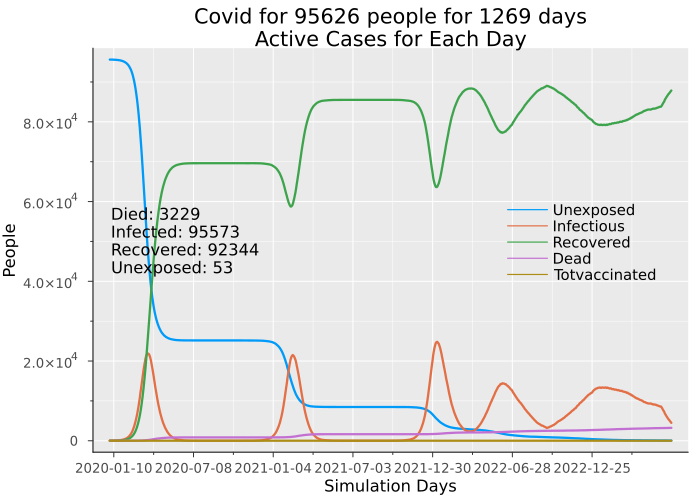

In [116]:
cumplot(series, locale, [:unexposed, :infectious, :recovered, :dead, :totvaccinated])

Note that the orange line labeled Infectious, which shows the current number of infected people, is *not* what you see in newspaper accounts. In this plot Infectious shows the net infected people: There were some sick people as of the day before. Some more people got sick today. Some people got better: they're not infectious any more--they recovered and are on the blue line. Sadly, some people died--they're not infectious either--they're dead and are on the green line. So net infected is yesterday + new today - recovered today - died today. Newspaper tracking shows the new infections of each day--who got sick today? Tomorrow, if no one new got sick the line would be at zero--even though the people who got sick yesterday are still infected. So, the newspaper line goes up and down faster and higher, because no one is ever subtracted. Yet another approach is to show the cumulative number of infected people: This keeps going up until no one new gets infected--then the line levels off. 

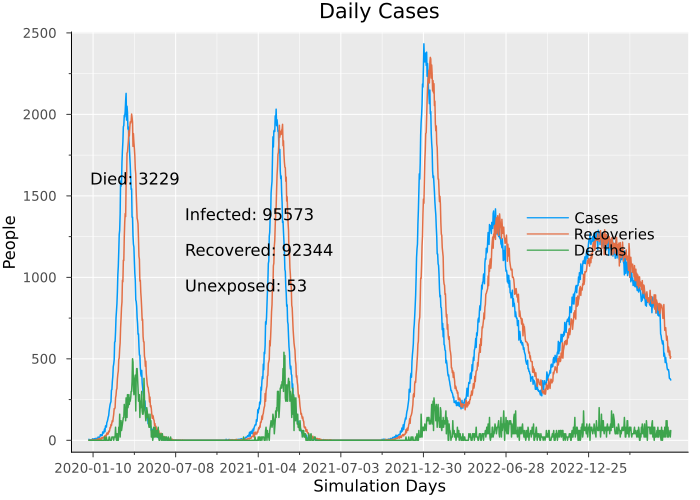

In [119]:
                  
cs.daily_cases_plot(series, popdat, locale, [:total]; geo=[])

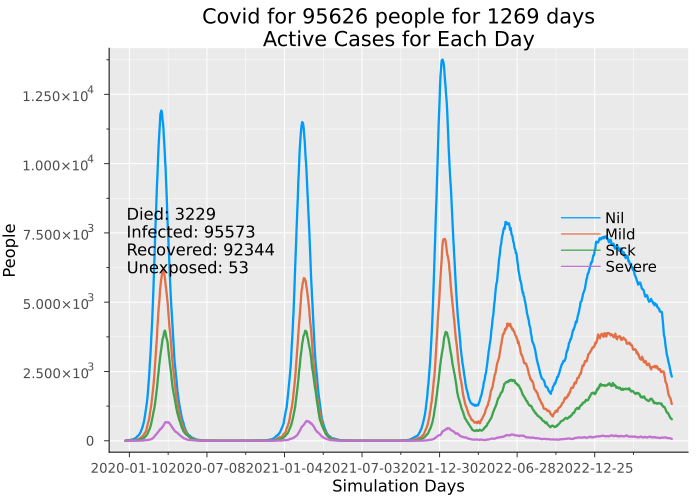

In [120]:
cumplot(series, locale, [:nil, :mild, :sick, :severe])

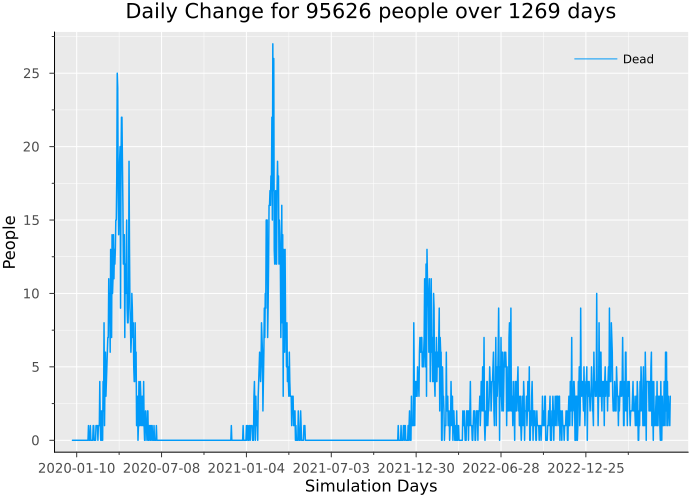

In [121]:
newplot(series, locale, [:dead])

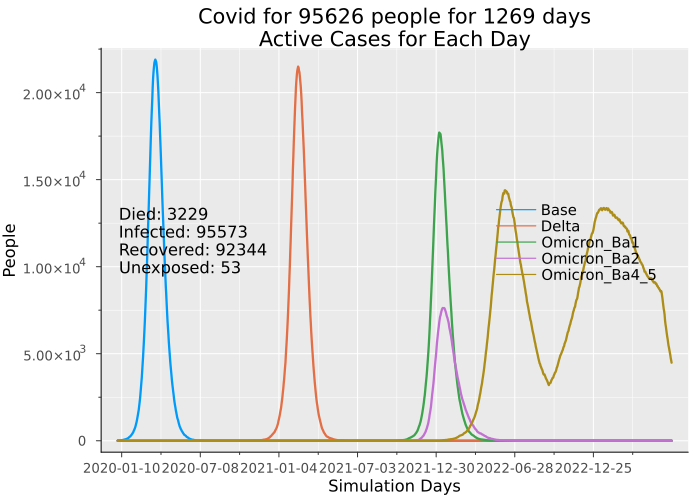

In [122]:
cumplot(series, locale, [:base, :delta, :omicron_ba1, :omicron_ba2, :omicron_ba4_5])

## Examine Vaccination process and outcomes

In [123]:
vax = :Pfizer
pfdose2 = count(length.(locdat.vaxrcvd[last.(locdat.vaxrcvd) .== vax]) .== 2)
pfdose1 = count(length.(locdat.vaxrcvd[last.(locdat.vaxrcvd) .== vax]) .== 1)
println("Count people with $vax 1 dose: $pfdose1 2 doses: $pfdose2 Any: $(pfdose1 + pfdose2)")
println("Doses used = $(2 * pfdose2 + pfdose1)")

Count people with Pfizer 1 dose: 0 2 doses: 0 Any: 0
Doses used = 0


In [124]:
vax = :Moderna
modose2 = count(length.(locdat.vaxrcvd[last.(locdat.vaxrcvd) .== vax]) .== 2)
modose1 = count(length.(locdat.vaxrcvd[last.(locdat.vaxrcvd) .== vax]) .== 1)
println("Count people with $vax 1 dose: $modose1 2 doses: $modose2 Any: $(modose1 + modose2)")
println("Doses used = $(2 * modose2 + modose1)")

Count people with Moderna 1 dose: 0 2 doses: 0 Any: 0
Doses used = 0


In [125]:
vax = :JnJ
# jjdose2 = count(length.(locdat.vaxrcvd[last.(locdat.vaxrcvd) .== vax]) .== 2)
jjdose1 = count(length.(locdat.vaxrcvd[last.(locdat.vaxrcvd) .== vax]) .== 1)
println("Count people with $vax 1 dose: $jjdose1 Any: $(jjdose1)")
println("Doses used = $(jjdose1)")

Count people with JnJ 1 dose: 0 Any: 0
Doses used = 0


In [126]:
println("People with any vaccine: $(pfdose2+pfdose1+modose2+modose1+jjdose1)")

People with any vaccine: 0


In [127]:
stat_cond = cs.stat_cond(series, locale)

Table with 13 columns and 5 rows:
     item           total  total_pct    age0_19  age0_19_pct  age20_39  ⋯
   ┌─────────────────────────────────────────────────────────────────────
 1 │ pop            95626  1.0          24002    1.0          25915     ⋯
 2 │ died           3229   0.033767     30       0.0012499    48        ⋯
 3 │ unexposed      53     0.000554243  53       0.00220815   0         ⋯
 4 │ ever_infected  95573  0.999446     23949    0.997792     25915     ⋯
 5 │ recovered      87859  0.918777     23435    0.976377     24464     ⋯

In [128]:
count(locdat.status .== infectious)

0

In [129]:
stat_cond.age80_up_pct

5-element Vector{Float64}:
 1.0
 0.46554035934566906
 0.0
 1.0
 0.49986591579511935

In [130]:
stat_vax = cs.stat_vax(popdat, locale)

Table with 13 columns and 4 rows:
     item     total  total_pct  age0_19  age0_19_pct  age20_39  age20_39_pct  ⋯
   ┌───────────────────────────────────────────────────────────────────────────
 1 │ none     95626  1.0        23972    1.0          25867     1.0           ⋯
 2 │ Moderna  0      0.0        0        0.0          0         0.0           ⋯
 3 │ Pfizer   0      0.0        0        0.0          0         0.0           ⋯
 4 │ JnJ      0      0.0        0        0.0          0         0.0           ⋯

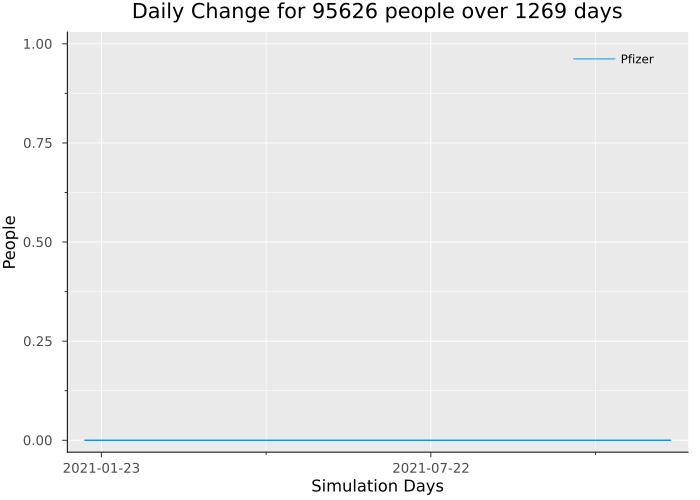

In [131]:
newplot(series, locale, [:Pfizer], days=380:700)

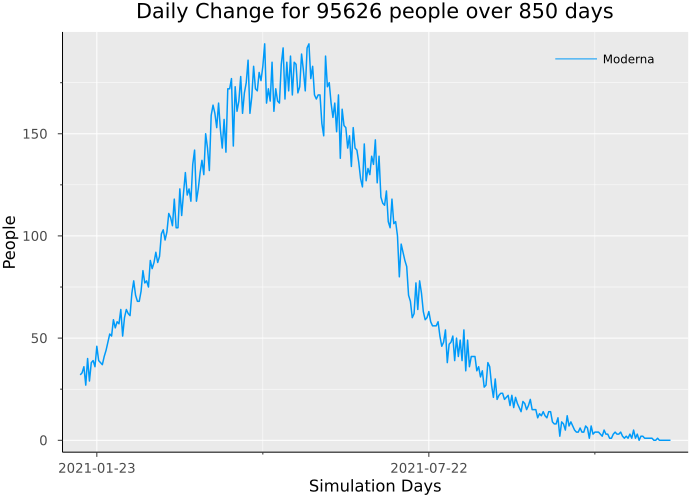

In [34]:
newplot(series, locale, [:Moderna], days=380:700)

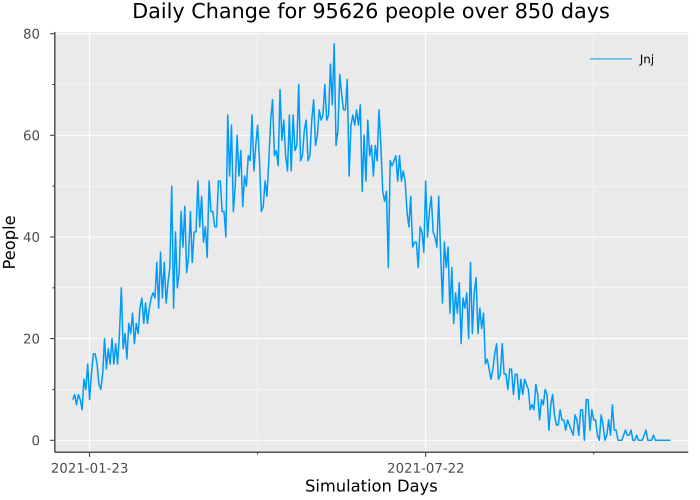

In [36]:
newplot(series, locale, :JnJ, days=380:700)

### Vaccine schedule 

In [ ]:
fieldnames(typeof(model.vaxschedset[:loc38015_old]))

(:vaxesincluded, :dayrange, :targetpct, :filtervec, :shotmode, :pattern, :spreadfunc)

In [ ]:
sf = model.vaxschedset[:loc38015_old].spreadfunc

In [ ]:
model.vaxschedset[:loc38015_old].dayrange

In [ ]:
model.vaxschedset[:loc38015_old].targetpct

In [ ]:
sum(sf.(350:700))

In [ ]:
plot(sf.(350:700))

In [ ]:
sum(sf.(350:2:700))  
# if you don't query all the days, you can get much less than the full sum--but we do query all days
# if you don't use all the allocation on a "big" day, you can't get that quantity back
# so what's the solution:
      # only impose a limit on the early days
      # then don't enforce any limit later
      # this can be easier than using the interpolation generator funcion
      # the called function should make the date range more obvious
      # the only consequence is running out early, but that is what would really happen
# is it better to have a limit on people or doses?
      # a limit on people is modeling the behavior of requesting the virus
      # a limit on doses is the real world of limited supply of vaccine
      # we are not going to track the number of people turned away, because 1) it doesn't matter; 2) the number generated
          # by the simulation has no relation to a similar problem in the real world
# should the limit be calculated on the no. of doses currently available or the original starting supply?
      # pct of what's left means we never use it up
      # pct of original supply means we never tap previous days unused doses
      # might be simpler to use doses / day such that all the vaccine is used up
      # we could also have an explict "request" schedule, especially for the early weeks

In [ ]:
struct sched
    pattern::Vector{Float64}
    startday::Int
end

In [ ]:
seq = [0.02, .05, .08, .15, .2, .24, .05, .05, .03, .03, .03, .03, .02, .02]

In [ ]:
s1 = sched(seq, 50)

In [ ]:
startqty = 1000

function dispense(startq, sch, day)
    if day < sch.startday
        return 0
    end
    weeknum = fld(day - sch.startday, 7) + 1
    #  portion = weeknum <= length(sch.pattern) ? sch.pattern[weeknum] : sch.pattern[end]
    weekportion = sch.pattern[max(weeknum, length(sch.pattern))]
    give = round(Int, (startq * weekportion) / 7, RoundDown)
end

In [ ]:
dispense(5_000, s1, 52)

In [ ]:
model.vaxschedset[:loc38015_old].vaxesincluded

In [ ]:
model.vaxschedset[:loc38015_old].vaxesincluded[:Moderna]

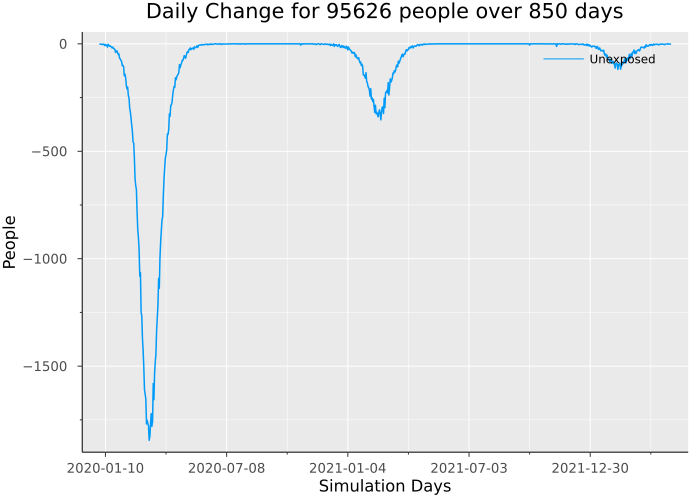

In [37]:
newplot(series, locale, :unexposed)




## How many people got sick multiple times?



In [75]:
sort(countmap(length.(locdat.variant)))

OrderedCollections.OrderedDict{Int64, Int64} with 6 entries:
  0 => 25743
  1 => 56487
  2 => 11888
  3 => 1415
  4 => 91
  5 => 2

### Breakout Infections

In [133]:
@Select(vaxday, sickday, agegrp)(locdat[((locdat.status .== infectious) .| (locdat.status .== recovered)) .& 
                            (locdat.vaxstatus .!= :none) .& (last.(locdat.sickday) .> first.(locdat.vaxday))])

Table with 3 columns and 0 rows:
     vaxday  sickday  agegrp
   ┌────────────────────────

### How many vaccinated people died?

In [24]:
@Select(agegrp, vaxday, sickday, deadday)(locdat[(locdat.status .== dead) .& (locdat.vaxstatus .!= :none)])

Table with 4 columns and 13 rows:
      agegrp    vaxday      sickday                      deadday
    ┌───────────────────────────────────────────────────────────
 1  │ age60_79  [454, 535]  [0, 74, 755, 773, 827]       841
 2  │ age60_79  [529, 555]  [0, 77, 90, 468, 797]        816
 3  │ age60_79  [435]       [0, 458]                     472
 4  │ age60_79  [506, 540]  [0, 99, 731, 741, 778, 804]  829
 5  │ age60_79  [488]       [0, 90, 522]                 536
 6  │ age60_79  [518, 570]  [0, 93, 778, 794]            808
 7  │ age60_79  [498, 546]  [0, 753, 782]                796
 8  │ age60_79  [448]       [0, 62, 455]                 474
 9  │ age80_up  [521, 546]  [0, 87, 769]                 794
 10 │ age80_up  [472, 531]  [0, 98, 811]                 825
 11 │ age80_up  [514, 546]  [0, 515, 782]                796
 12 │ age80_up  [400, 566]  [0, 792]                     817
 13 │ age80_up  [503, 533]  [0, 76, 764, 777]            802

## Test a social distancing case

In [38]:
sd1 = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, include_ages=[])    

(::CovidSim_ilm.var"#caserunner#148"{CovidSim_ilm.var"#caserunner#147#149"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{Any}}}) (generic function with 1 method)

In [40]:
sd1_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, include_ages=[])

(::CovidSim_ilm.var"#caserunner#148"{CovidSim_ilm.var"#caserunner#147#149"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{Any}}}) (generic function with 1 method)

In [41]:
popdat, series = runsim(model;
            dovax=true, vaxscheds=:all, showr0=false, silent=true, 
            runcases=[seed20_39_day1, seed40_59_day1, seed20_39_delta, seed40_59_delta, seed20_39_omicron, seed40_59_omicron,
                      seed20_39_omicron_ba2, seed40_59_omicron_ba2, seed20_39_omicron_ba4_5, 
                      seed40_59_omicron_ba4_5, sd1, sd1_end]);
locdat = popdat[locale];

*** seed day 1 count: 3 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, sickday=1, variant=:base, duration=1, ]
*** seed day 1 count: 3 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, sickday=1, variant=:base, duration=1, ]
*** seed day 300 count: 3 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, sickday=300, variant=:delta, duration=1, ]
*** seed day 300 count: 3 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, sickday=300, variant=:delta, duration=1, ]
*** seed day 640 count: 3 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, sickday=640, variant=:omicron_ba1, duration=1, ]
*** seed day 640 count: 3 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, sickday=640, variant=:omicron_ba1, duration=1, ]
*** seed day 680 count: 6 filter: [agegrp=age20_39, status=unexposed, ] change: 

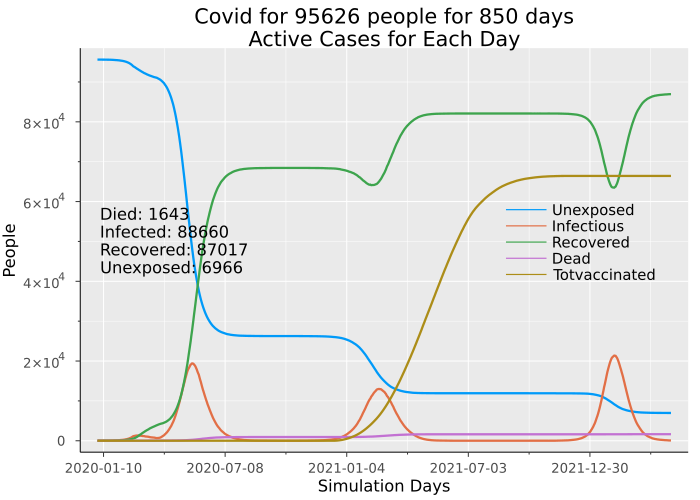

In [42]:
cumplot(series, locale, [:unexposed, :infectious, :recovered, :dead, :totvaccinated])

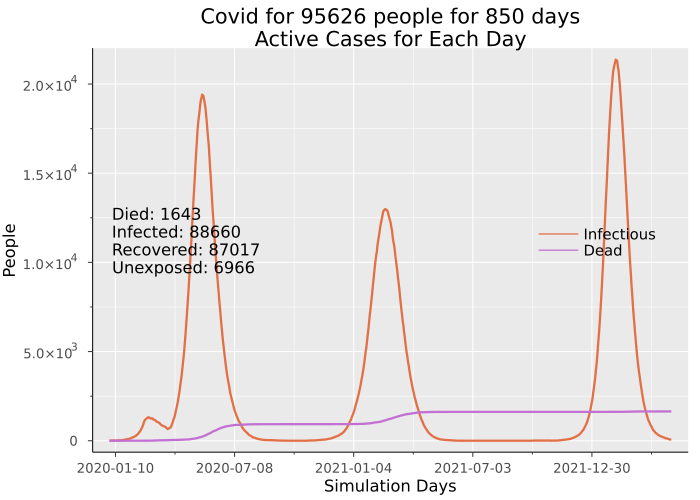

In [43]:
cumplot(series, locale,[:infectious, :dead])

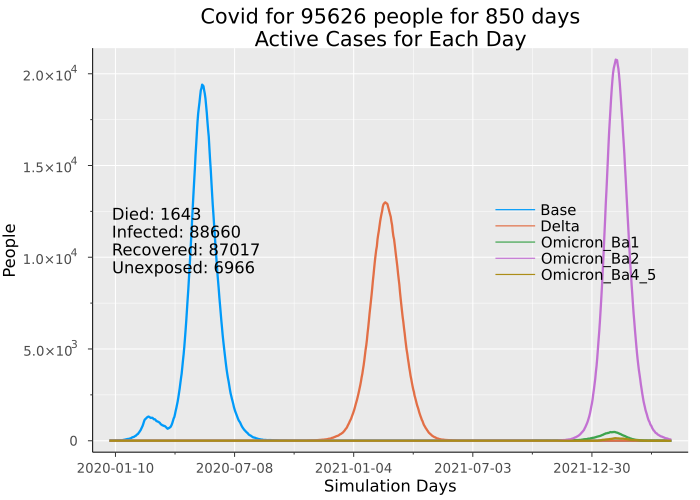

In [44]:
cumplot(series, locale,[:base, :delta, :omicron_ba1, :omicron_ba2, :omicron_ba4_5])

## Social distancing only among those age40_59, age60_79, age80_plus

In [36]:
sdolder = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])    

(::CovidSim_ilm.var"#caserunner#148"{CovidSim_ilm.var"#caserunner#147#149"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{Agegrp}}}) (generic function with 1 method)

In [37]:
sdolder_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])    

(::CovidSim_ilm.var"#caserunner#148"{CovidSim_ilm.var"#caserunner#147#149"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{Agegrp}}}) (generic function with 1 method)

In [38]:
popdat, series = runsim(model; 
                        dovax=true, vaxscheds=:all,
                        runcases=[seed20_39_day1, seed40_59_day1, seed20_39_delta, seed40_59_delta, 
                                  seed20_39_omicron, seed40_59_omicron,
                                  seed20_39_omicron_ba2, seed40_59_omicron_ba2, seed20_39_omicron_ba4_5, seed40_59_omicron_ba4_5,
                                  sdolder, sdolder_end]);
locdat = popdat[locale];

*** seed day 1 count: 3 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, sickday=1, variant=:base, duration=1, ]
*** seed day 1 count: 3 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, sickday=1, variant=:base, duration=1, ]
*** seed day 300 count: 3 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, sickday=300, variant=:delta, duration=1, ]
*** seed day 300 count: 3 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, sickday=300, variant=:delta, duration=1, ]
*** seed day 640 count: 3 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, sickday=640, variant=:omicron_ba1, duration=1, ]
*** seed day 640 count: 3 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, sickday=640, variant=:omicron_ba1, duration=1, ]
*** seed day 680 count: 6 filter: [agegrp=age20_39, status=unexposed, ] change: 

In [40]:
olderdat =popdat[locale]

sd = findall(olderdat.sdcase .!= :none)

@Select(agegrp, sdcase)(olderdat[sd])

Table with 2 columns and 0 rows:
     agegrp  sdcase
   ┌───────────────

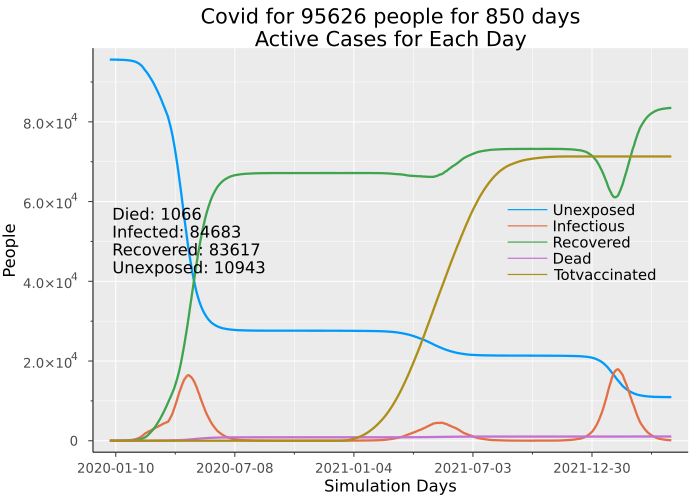

In [41]:
cumplot(series, locale, [:unexposed, :infectious, :recovered, :dead, :totvaccinated])

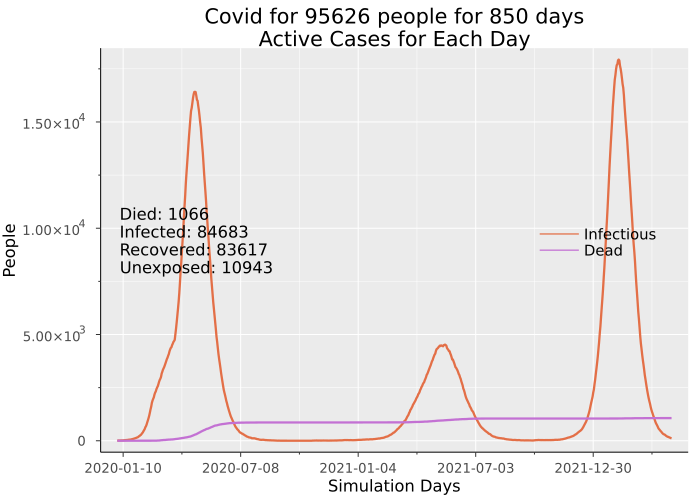

In [42]:
cumplot(series, locale, [:infectious, :dead])

## Social Distancing starts with everyone and then the younger folks party

In [43]:
sdyoung_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, 
    include_ages=[age0_19, age20_39])    

(::CovidSim_ilm.var"#caserunner#148"{CovidSim_ilm.var"#caserunner#147#149"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{Agegrp}}}) (generic function with 1 method)

In [51]:
popdat, series = runsim(model,
                        dovax=true, vaxscheds=:all,
                        runcases=[seed20_39_day1, seed40_59_day1, seed20_39_delta, seed40_59_delta, 
                                  seed20_39_omicron, seed40_59_omicron, seed20_39_omicron_ba2, 
                                  seed40_59_omicron_ba2, seed20_39_omicron_ba4_5, seed40_59_omicron_ba4_5,
                                  sd1, sdyoung_end]);
locdat = popdat[locale];

*** seed day 1 count: 3 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, sickday=1, variant=:base, duration=1, ]
*** seed day 1 count: 3 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, sickday=1, variant=:base, duration=1, ]
*** seed day 300 count: 3 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, sickday=300, variant=:delta, duration=1, ]
*** seed day 300 count: 3 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, sickday=300, variant=:delta, duration=1, ]
*** seed day 640 count: 3 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, sickday=640, variant=:omicron_ba1, duration=1, ]
*** seed day 640 count: 3 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, sickday=640, variant=:omicron_ba1, duration=1, ]
*** seed day 680 count: 6 filter: [agegrp=age20_39, status=unexposed, ] change: 

In [45]:
mixdat = popdat[locale]

sd = findall(mixdat.sdcase .!= :none)
young = findall((mixdat.agegrp .== age0_19) .| (mixdat.agegrp .== age20_39))
sd_young_idx = intersect(sd, young)
old = findall((mixdat.agegrp .== age40_59) .| (mixdat.agegrp .== age60_79) .| (mixdat.agegrp .== age80_up));

In [46]:
youngtab = Table(mixdat[young])
count(youngtab.sdcase .== :none)

49917

In [47]:
oldtab = Table(mixdat[old])
count(oldtab.sdcase .!= :none)

40956

In [48]:
typeof(mixdat.agegrp)

Vector{Agegrp} (alias for Array{Agegrp, 1})

In [49]:
mixdat = popdat[locale]

Table with 17 columns and 95626 rows:
      status     agegrp   cond        duration  variant         sickday   ⋯
    ┌──────────────────────────────────────────────────────────────────────
 1  │ unexposed  age0_19  uninfected  0         Symbol[]        [0]       ⋯
 2  │ unexposed  age0_19  uninfected  0         Symbol[]        [0]       ⋯
 3  │ unexposed  age0_19  uninfected  0         Symbol[]        [0]       ⋯
 4  │ unexposed  age0_19  uninfected  0         Symbol[]        [0]       ⋯
 5  │ recovered  age0_19  uninfected  9         [:base]         [0, 54]   ⋯
 6  │ unexposed  age0_19  uninfected  0         Symbol[]        [0]       ⋯
 7  │ unexposed  age0_19  uninfected  0         Symbol[]        [0]       ⋯
 8  │ recovered  age0_19  uninfected  9         [:omicron_ba2]  [0, 840]  ⋯
 9  │ unexposed  age0_19  uninfected  0         Symbol[]        [0]       ⋯
 10 │ unexposed  age0_19  uninfected  0         Symbol[]        [0]       ⋯
 11 │ unexposed  age0_19  uninfected  0         Sy

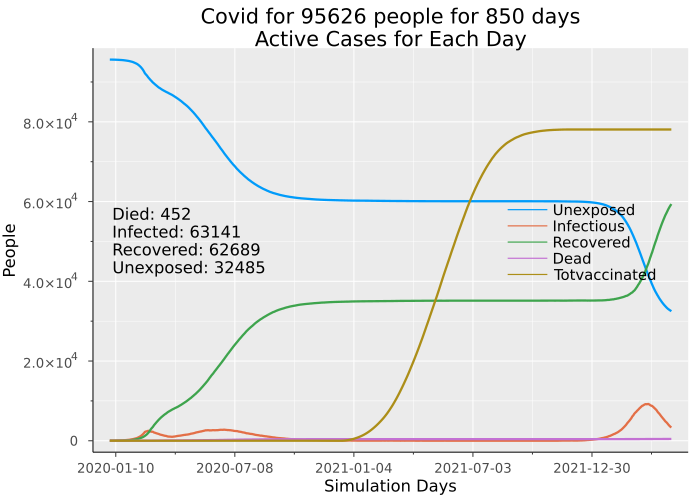

In [52]:
cumplot(series, locale, [:unexposed, :infectious, :recovered, :dead, :totvaccinated])

In [ ]:
@Select(status, agegrp, cond, sdcomply)(locdat)

# Evaluate squashing functions

In [13]:
xs = collect(0.01:0.01:2.5)

250-element Vector{Float64}:
 0.01
 0.02
 0.03
 0.04
 0.05
 0.06
 0.07
 0.08
 0.09
 0.1
 0.11
 0.12
 0.13
 ⋮
 2.39
 2.4
 2.41
 2.42
 2.43
 2.44
 2.45
 2.46
 2.47
 2.48
 2.49
 2.5

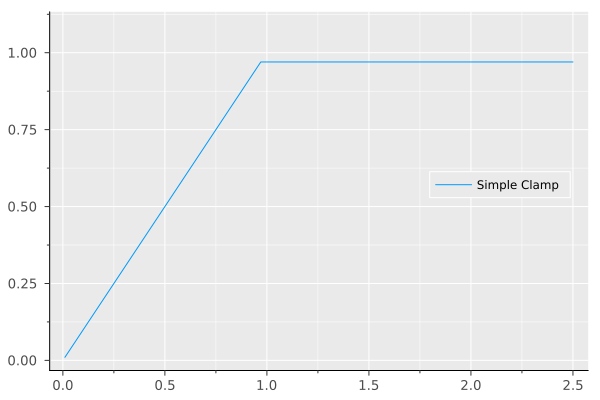

In [19]:
plot(xs, cs.simpleclamp.(xs), label="Simple Clamp", ylims=[0.0, 1.1], legend=:right)

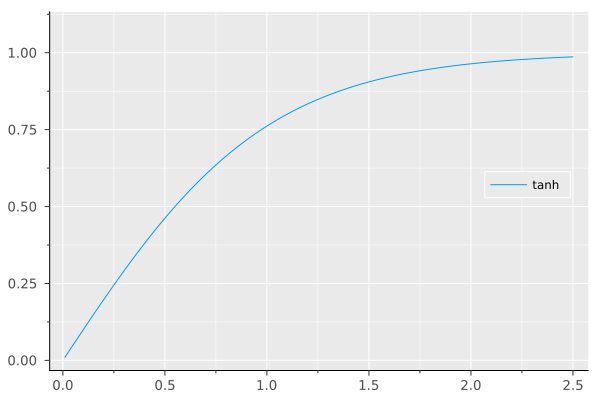

In [20]:
plot(xs, tanh.(xs), label="tanh", legend=:right, ylims=[0.0, 1.1])

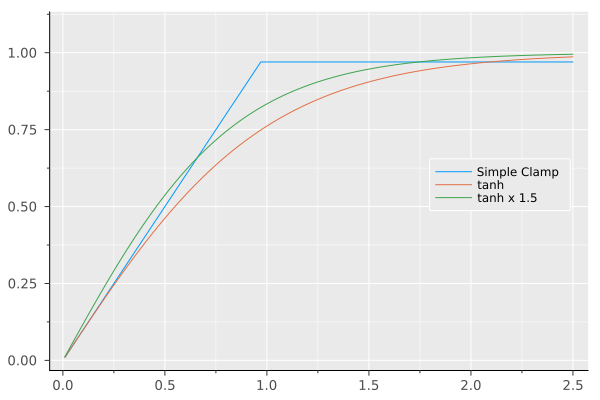

In [69]:
plot(xs, cs.simpleclamp.(xs), label="Simple Clamp", ylims=[0.0, 1.1], legend=:right)
plot!(xs, tanh.(xs), label="tanh", legend=:right, ylims=[0.0, 1.1])
plot!(xs, tanh.((1.2 .* xs)), label="tanh x 1.5", legend=:right, ylims=[0.0, 1.1])
# plot!(xs, cs.sigmoid.((8.0 .* xs) .- 3.9), label="sigmoid((8.0 * x) - 3.9) ", legend=:right, ylims=[0.0, 1.1])

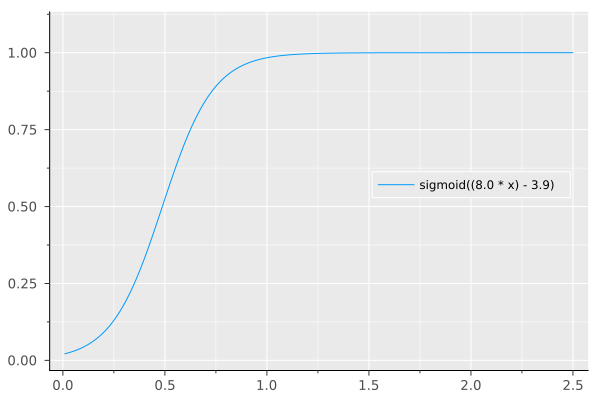

In [67]:
plot(xs, cs.sigmoid.((8.0 .* xs) .- 3.9), label="sigmoid((8.0 * x) - 3.9) ", legend=:right, ylims=[0.0, 1.1])

In [23]:
@btime cs.simpleclamp.(xs)

  470.728 ns (3 allocations: 2.09 KiB)


250-element Vector{Float64}:
 0.01
 0.02
 0.03
 0.04
 0.05
 0.06
 0.07
 0.08
 0.09
 0.1
 0.11
 0.12
 0.13
 ⋮
 0.97
 0.97
 0.97
 0.97
 0.97
 0.97
 0.97
 0.97
 0.97
 0.97
 0.97
 0.97

In [24]:
471.0 / 250.0

1.884

In [25]:
@btime tanh.(xs)

  2.032 μs (3 allocations: 2.09 KiB)


250-element Vector{Float64}:
 0.00999966667999946
 0.01999733375993093
 0.029991003238820143
 0.03997868031116357
 0.04995837495787998
 0.059928103529143496
 0.069885890316429
 0.07982976911113136
 0.0897577847471601
 0.09966799462495582
 0.10955847021442953
 0.11942729853438588
 0.12927258360605834
 ⋮
 0.9833478138031324
 0.9836748576936802
 0.9839955303715675
 0.9843099539390887
 0.9846182482369833
 0.9849205308832533
 0.985216917311436
 0.9855075208083371
 0.9857924525512225
 0.9860718216444758
 0.9863457351557237
 0.9866142981514303

In [26]:
2000.0 / 250.0

8.0